# 0. Base

In [70]:
import pandas as pd
import re
import matplotlib.pyplot as plt


In [44]:
# base code-block: 0
# default setting of plotting parameters
label_size = 12
# plot_params = {
#     "font.family": "Arial",
#     "figure.dpi": 100,
#     "savefig.format": 'svg',
#     "xtick.labelsize": 10,
#     "ytick.labelsize": 10,
#     "legend.fontsize": 10,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "axes.labelweight": "bold"
# }

plot_params = {
    # font setting 
    "font.family": "Arial",
    "axes.labelsize": label_size,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": label_size + 2,

    # dpi setting
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.format": "svg",

    # tick setting
    "xtick.labelsize": label_size,
    "ytick.labelsize": label_size,
    "axes.labelweight": "bold",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    # 刻度文字加粗
    "xtick.major.pad": 6,
    "ytick.major.pad": 6,

    # legend
    "legend.fontsize": label_size,
    "legend.frameon": False, # legend 是否有框

    # frame
    "axes.linewidth": 1.2,
 
    # grid 背景是否有网格
    "axes.grid": False,     # True / False on/off
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.5,

}

plt.rcParams.update(plot_params)

# 1. Tools

## 1.1. Data Process

In [73]:

def voltage_capacity_process(cycle_list, 
                             raw_data, 
                             normalization=False 
                             # 是否归一化(充放电容量同时除以最大值)
                            ):
    """
     根据raw的数据处理获得可以画图的数据
     注意raw_data是新威的报表，必须是英文，记录层数据（recording layer）, 勾选step type, voltage, spec.cap
     
    """
    cycle_data = pd.DataFrame(data=None)
    for i in cycle_list:
        new_columns = ["Voltage_charge_"+str(i), "Capacity_charge_"+str(i),
                   "Voltage_discharge_"+str(i), "Capacity_discharge_"+str(i)]
        df_cycle = curve_data[curve_data['Cycle Index'] == i]
        df_charge_i = df_cycle[df_cycle['Step Type'] == "CC Chg"][["Voltage", "Spec. Cap."]].reset_index(drop=True)
        df_charge_i.rename(columns={'Voltage': new_columns[0], "Spec. Cap.": new_columns[1]}, inplace=True)
        df_discharge_i = df_cycle[df_cycle['Step Type'] == "CC DChg"][["Voltage", "Spec. Cap."]].reset_index(drop=True)
        df_discharge_i.rename(columns={'Voltage': new_columns[2], "Spec. Cap.": new_columns[3]}, inplace=True)
        cycle_data = pd.concat([cycle_data, df_charge_i, df_discharge_i], axis=1)

    if normalization: # 如果normalization是TRUE,那么进行归一化（看电压衰退），此
        capacity_column = []
        for i in cycle_data.columns:
            if i.startswith("Capacity"):
                capacity_column.append(i)
        
        cycle_data[capacity_column] = cycle_data[capacity_column].div(
            cycle_data[capacity_column].max(skipna=True)
        )
        
    return cycle_data

# 1.2 Plotting

In [58]:
# 绘制capacity-Voltage的曲线
def ordinal(n):
    """Convert integer to ordinal string (1 -> 1st, 2 -> 2nd, etc.)"""
    if 10 <= n % 100 <= 20:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"


def plot_charge_discharge(
    df,
    title="Charge-Discharge Curves", 
    x_label="Capacity",
    y_label="Voltage(V)", 
    ax=None,
    color_list=None,
    legend_list=None,
):
    """
    画处理过的充放电循环数据。输入必须是cycle_data的格式
    Plot charge-discharge curves (Capacity vs Voltage).
    Parameters
    df : pandas.DataFrame
    ax : matplotlib.axes.Axes, optional
        Axis to plot on. If None, a new figure and axis will be created.
    color_list : list, optional
        List of colors for each cycle.
    legend_list : list, optional
        Custom legend labels
    Returns
    ax : matplotlib.axes.Axes
    """


    if ax is None:
        fig, ax = plt.subplots()


    cycle_pattern = r"Voltage_charge_(\d+)"
    cycles = sorted(
        [int(re.search(cycle_pattern, col).group(1))
         for col in df.columns if re.search(cycle_pattern, col)]
    )

    n_cycles = len(cycles)

    if n_cycles == 0:
        raise ValueError("No charge-discharge cycles detected.")


    if color_list is not None:
        if len(color_list) != n_cycles:
            raise ValueError(
                f"Length of color_list ({len(color_list)}) "
                f"must equal number of cycles ({n_cycles})."
            )
    else:
        cmap = plt.cm.viridis
        if n_cycles == 1:
            color_list = [cmap(0.5)]
        else:
            color_list = [cmap(i / (n_cycles - 1)) for i in range(n_cycles)]


    if legend_list is not None:
        if len(legend_list) != n_cycles:
            raise ValueError(
                f"Length of legend_list ({len(legend_list)}) "
                f"must equal number of cycles ({n_cycles})."
            )
    else:
        legend_list = [f"{ordinal(cycle)} cycle" for cycle in cycles]


    for idx, cycle in enumerate(cycles):

        color = color_list[idx]
        label = legend_list[idx]

        v_charge = f"Voltage_charge_{cycle}"
        c_charge = f"Capacity_charge_{cycle}"
        v_dis = f"Voltage_discharge_{cycle}"
        c_dis = f"Capacity_discharge_{cycle}"

        charge_df = df[[c_charge, v_charge]].dropna()
        discharge_df = df[[c_dis, v_dis]].dropna()

        # charge（加 legend）
        ax.plot(
            charge_df[c_charge],
            charge_df[v_charge],
            linestyle='-',
            color=color,
            label=label
        )

        # discharge（不加 legend）
        ax.plot(
            discharge_df[c_dis],
            discharge_df[v_dis],
            linestyle='-',
            color=color
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend()

    return ax

# 2. Plotting Station

In [6]:
curve_data = pd.read_csv("experimental_data/Li2Ni0.5Ru0.5O2.csv")

In [8]:
cycle_number = len(set(curve_data["Cycle Index"].values))
cycle_number

100

In [71]:
cycle_data = voltage_capacity_process(cycle_list=[1],
                                raw_data=cycle_number,
                                normalization=True
                               )

In [30]:
cycle_data_norm.to_csv("Li2Ni0.5Ru0.5O2.csv", index=False)

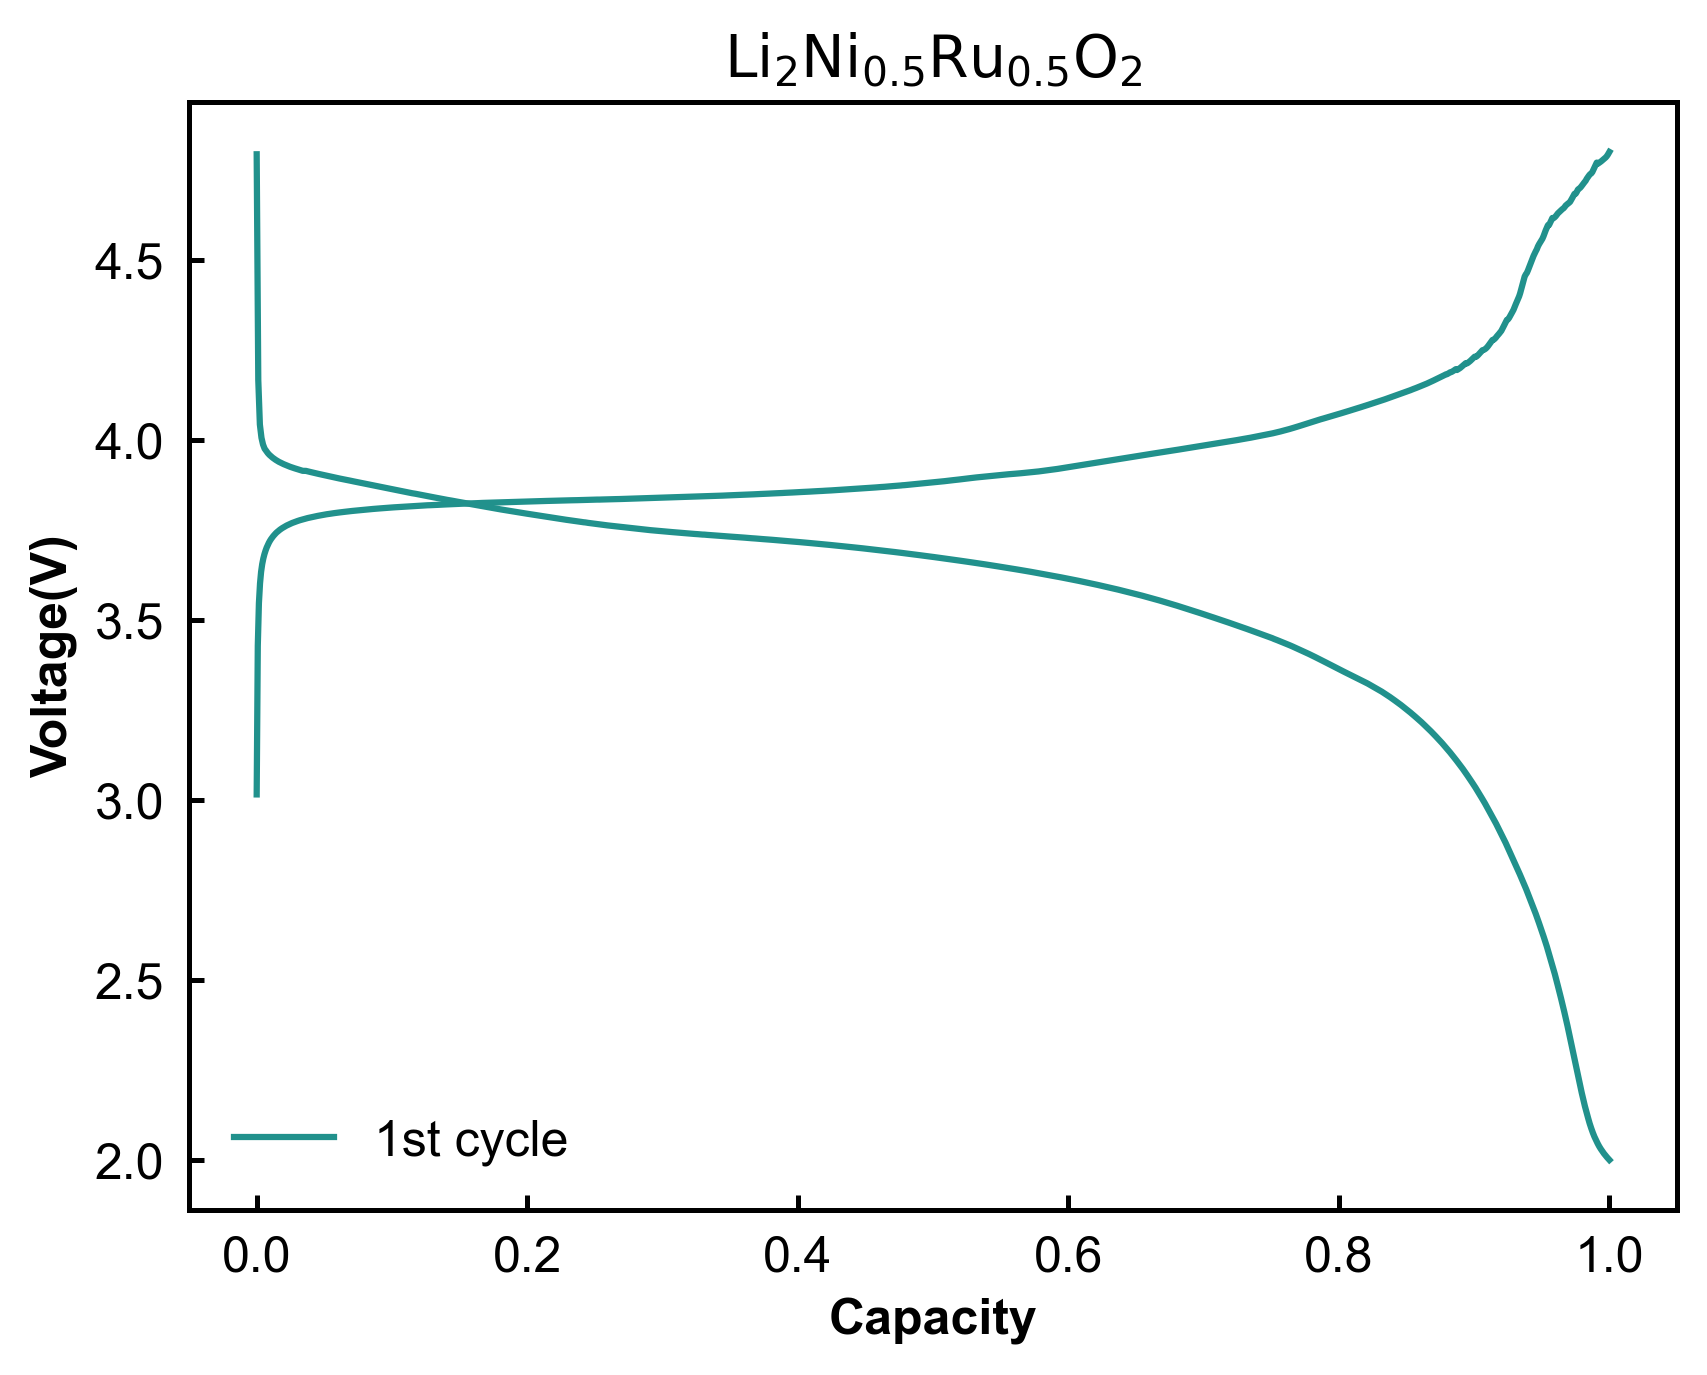

In [72]:
ax = plot_charge_discharge(cycle_data, title="$\mathbf{\mathrm{Li_2Ni_{0.5}Ru_{0.5}O_2}}$")
plt.show()